# Preprocessing Pipeline: Scopus Literature Sample

**Project:** Management Accounting Research — Systematic Literature Review  
**Data source:** Scopus export of 7 accounting journals, 2021–2026  
**File:** `Scopus_Screening_results.xlsx`  

This notebook documents the full preprocessing pipeline applied to the raw Scopus dataset before topic modelling and analysis. Each step is reproducible and self-contained.

---

## Requirements

| Package | Purpose |
|---|---|
| `pandas` | Data loading, filtering, and manipulation |
| `matplotlib` | Plotting |
| `seaborn` | Statistical visualisations and heatmaps |
| `nltk` | English stopword list |
| `re` | Regular expressions for text cleaning |
| `openpyxl` | Excel file reading backend |

Run the cell below to install any missing packages.

In [1]:
# Core imports
import re
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import nltk

warnings.filterwarnings("ignore")

# Download NLTK stopwords (skipped automatically if already present)
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

# Plotting defaults
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Path to input file — adjust if needed
DATA_FILE = "Scopus_Screening_results.xlsx"

print("Imports successful.")

Imports successful.


---

## Step 1 — Load & Inspect

We load the `Results` tab of the Scopus export and perform a first inspection: shape, column types, and missing value counts. We also check the distribution of `Document Type`, `Source title`, and `Year` to understand the composition of the raw dataset.

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
df_raw = pd.read_excel(DATA_FILE, sheet_name="Results", dtype=str)

# Strip whitespace from column names to avoid silent key errors
df_raw.columns = df_raw.columns.str.strip()

print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns\n")
print("Column names:")
print(df_raw.columns.tolist(), "\n")

print("Data types:")
print(df_raw.dtypes, "\n")

missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_report = pd.DataFrame({"Missing count": missing, "Missing %": missing_pct})
missing_report = missing_report[missing_report["Missing count"] > 0].sort_values("Missing count", ascending=False)
print("Columns with missing values:")
display(missing_report)

Shape: 2,675 rows × 22 columns

Column names:
['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year', 'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end', 'Cited by', 'DOI', 'Link', 'Abstract', 'Author Keywords', 'Index Keywords', 'Document Type', 'Publication Stage', 'Open Access', 'Source', 'EID'] 

Data types:
Authors              object
Author full names    object
Author(s) ID         object
Title                object
Year                 object
Source title         object
Volume               object
Issue                object
Art. No.             object
Page start           object
Page end             object
Cited by             object
DOI                  object
Link                 object
Abstract             object
Author Keywords      object
Index Keywords       object
Document Type        object
Publication Stage    object
Open Access          object
Source               object
EID                  object
dtype: object 

Columns with missing va

,Missing count,Missing %
Index Keywords,2675,100.0
Art. No.,2115,79.1
Open Access,1549,57.9
Page end,680,25.4
Page start,676,25.3
Issue,369,13.8
Volume,108,4.0
Author Keywords,82,3.1


In [3]:
# ── Value counts ──────────────────────────────────────────────────────────────
print("=== Document Type ===")
print(df_raw["Document Type"].value_counts().to_string(), "\n")

print("=== Source title ===")
print(df_raw["Source title"].value_counts().to_string(), "\n")

print("=== Year ===")
print(df_raw["Year"].value_counts().sort_index().to_string())

=== Document Type ===
Document Type
Article             2633
Review                33
Conference paper       9 

=== Source title ===
Source title
Accounting Review                            505
Contemporary Accounting Research             472
Review of Accounting Studies                 359
European Accounting Review                   307
Journal of Accounting and Economics          284
Journal of Accounting Research               255
Accounting, Organizations and Society        178
Journal of Management Accounting Research    144
Journal of Management Control                 88
Management Accounting Research                83 

=== Year ===
Year
2021    443
2022    436
2023    509
2024    555
2025    587
2026    145


---

## Step 2 — Filter: Keep Articles Only

Scopus exports include various document types (editorials, book chapters, reviews, etc.). For this analysis we retain only records where `Document Type == 'Article'`, as these represent peer-reviewed empirical and conceptual research papers.

In [4]:
n_before = len(df_raw)

df = df_raw[df_raw["Document Type"].str.strip() == "Article"].copy()
df.reset_index(drop=True, inplace=True)

n_after = len(df)
n_dropped = n_before - n_after

print(f"Rows before filter : {n_before:>6,}")
print(f"Rows dropped       : {n_dropped:>6,}")
print(f"Rows remaining     : {n_after:>6,}")

Rows before filter :  2,675
Rows dropped       :     42
Rows remaining     :  2,633


---

## Step 3 — Handle Missing Abstracts

Papers without usable abstracts are excluded from text-based analyses. We treat as missing:
- `NaN` / blank strings  
- The Scopus placeholder `[No abstract available]`  

Removed papers are reported before deletion so they can be audited if needed.

In [5]:
n_before_abs = len(df)

# Normalise: fill NaN with empty string, strip whitespace
df["Abstract"] = df["Abstract"].fillna("").str.strip()

# Flag placeholders and empty strings
PLACEHOLDER_PATTERN = re.compile(r"^\[no abstract available\]$", re.IGNORECASE)

mask_missing = (
    (df["Abstract"] == "") |
    df["Abstract"].str.match(PLACEHOLDER_PATTERN)
)

missing_abstracts = df[mask_missing][["Title", "Source title", "Year", "Abstract"]]
print(f"Papers with missing/placeholder abstracts: {mask_missing.sum()}")
if len(missing_abstracts) > 0:
    display(missing_abstracts)

df = df[~mask_missing].copy()
df.reset_index(drop=True, inplace=True)

n_after_abs = len(df)
print(f"\nRows before abstract filter : {n_before_abs:>6,}")
print(f"Rows dropped               : {n_before_abs - n_after_abs:>6,}")
print(f"Rows remaining             : {n_after_abs:>6,}")

Papers with missing/placeholder abstracts: 8


,Title,Source title,Year,Abstract
623,New Directions in Auditing Research: Conceptua...,European Accounting Review,2021,[No abstract available]
1261,Sustaining discreditable accounting research t...,"Accounting, Organizations and Society",2021,[No abstract available]
1305,When and why tangible rewards can motivate gre...,"Accounting, Organizations and Society",2023,[No abstract available]
1310,"Projecting, infrastructuring and calculating: ...","Accounting, Organizations and Society",2024,[No abstract available]
1339,Accounting for sustainability and climate chan...,"Accounting, Organizations and Society",2024,[No abstract available]
1399,The moderating effects of management's Non-GAA...,"Accounting, Organizations and Society",2026,[No abstract available]
1415,Discussion of “The ESG stopping effect: Do inv...,"Accounting, Organizations and Society",2024,[No abstract available]
2421,"Learning in the Past, Looking to the Future: J...",Journal of Management Accounting Research,2022,[No abstract available]



Rows before abstract filter :  2,633
Rows dropped               :      8
Rows remaining             :  2,625


---

## Step 4 — Text Cleaning

We produce two derived text columns:

1. **`abstract_clean`** — a normalised, de-noised version of the abstract for bag-of-words or TF-IDF analyses:
   - Lowercase
   - HTML tags and special characters removed (only alphanumerics and spaces retained)
   - Standard English stopwords removed (NLTK)
   - Accounting-domain stopwords removed (highly frequent but semantically uninformative terms in this corpus)
   - Extra whitespace collapsed

2. **`text_for_modeling`** — the raw concatenation `Title + '. ' + Abstract` (uncleaned). This preserves sentence structure and is intended as input for sentence-transformer models such as BERTopic, which handle their own tokenisation.

In [6]:
# ── Stopword sets ──────────────────────────────────────────────────────────────
EN_STOPWORDS = set(stopwords.words("english"))

ACCOUNTING_STOPWORDS = {
    "paper", "study", "find", "result", "research", "using", "use", "based",
    "suggest", "examine", "provide", "show", "article", "analysis", "propose",
    "review", "literature", "evidence", "data", "effect", "investigate", "also",
    "however", "may", "journal"
}

ALL_STOPWORDS = EN_STOPWORDS | ACCOUNTING_STOPWORDS

# ── Cleaning function ──────────────────────────────────────────────────────────
def clean_abstract(text: str) -> str:
    """Normalise an abstract for bag-of-words / TF-IDF use."""
    # Lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)
    # Keep only alphanumeric characters and spaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    # Tokenise, remove stopwords, and rejoin
    tokens = [t for t in text.split() if t not in ALL_STOPWORDS and len(t) > 1]
    # Collapse extra whitespace
    return " ".join(tokens)

# ── Apply ──────────────────────────────────────────────────────────────────────
df["abstract_clean"] = df["Abstract"].apply(clean_abstract)

# Concatenate Title + Abstract (raw) for sentence-transformer input
df["Title"] = df["Title"].fillna("").str.strip()
df["text_for_modeling"] = df["Title"] + ". " + df["Abstract"]

# Preview
print("Sample — original abstract:")
print(df["Abstract"].iloc[0][:300], "...\n")
print("Sample — cleaned abstract:")
print(df["abstract_clean"].iloc[0][:300], "...")

Sample — original abstract:
Auditor knowledge is a key element in explaining the supply of audit quality, yet understanding of the drivers of this knowledge in the archival literature is limited. This study uses an archival approach to examine whether the sharing of auditors among firms in banking relationships results in info ...

Sample — cleaned abstract:
auditor knowledge key element explaining supply audit quality yet understanding drivers knowledge archival limited uses archival approach whether sharing auditors among firms banking relationships results information transfers improve audit quality audit quality improves borrowers lenders share audi ...


---

## Step 5 — Journal & Year Distribution

We visualise the distribution of papers across journals and publication years, and produce a journal × year heatmap to reveal potential coverage gaps.

In [7]:
# ── Counts ─────────────────────────────────────────────────────────────────────
journal_counts = df["Source title"].value_counts()
year_counts = df["Year"].value_counts().sort_index()

print("Papers by journal:")
print(journal_counts.to_string())
print("\nPapers by year:")
print(year_counts.to_string())

Papers by journal:
Source title
Accounting Review                            474
Contemporary Accounting Research             471
Review of Accounting Studies                 358
European Accounting Review                   306
Journal of Accounting and Economics          276
Journal of Accounting Research               255
Accounting, Organizations and Society        171
Journal of Management Accounting Research    143
Journal of Management Control                 88
Management Accounting Research                83

Papers by year:
Year
2021    418
2022    429
2023    499
2024    550
2025    585
2026    144


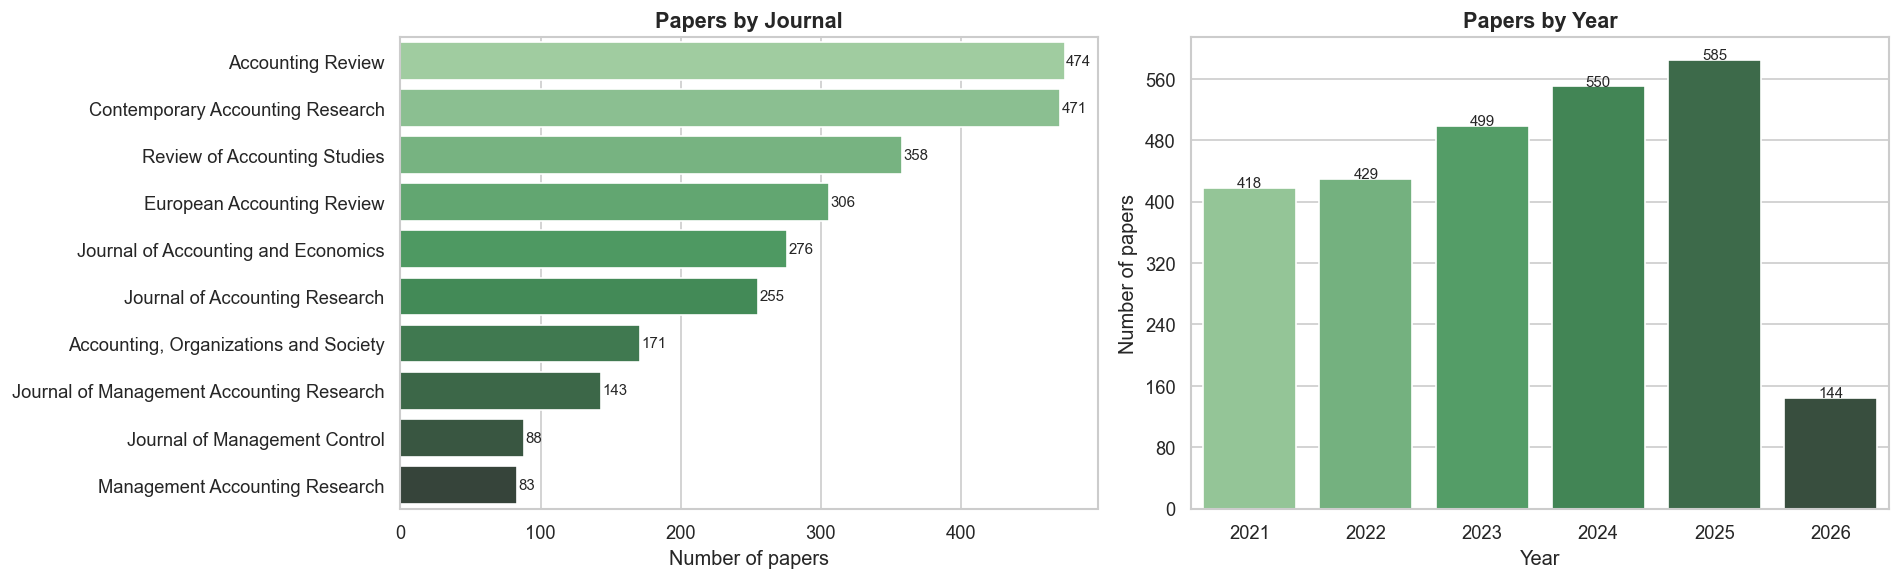

Figure saved as fig_distribution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart — journals
sns.barplot(
    x=journal_counts.values,
    y=journal_counts.index,
    ax=axes[0],
    palette="Greens_d"
)
axes[0].set_title("Papers by Journal", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of papers")
axes[0].set_ylabel("")
for bar in axes[0].patches:
    axes[0].text(
        bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width())}", va="center", fontsize=9
    )

# Bar chart — years
sns.barplot(
    x=year_counts.index.astype(str),
    y=year_counts.values,
    ax=axes[1],
    palette="Greens_d"
)
axes[1].set_title("Papers by Year", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of papers")
axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
        f"{int(bar.get_height())}", ha="center", fontsize=9
    )

plt.tight_layout()
plt.savefig("fig_distribution.png", bbox_inches="tight")
plt.show()
print("Figure saved as fig_distribution.png")

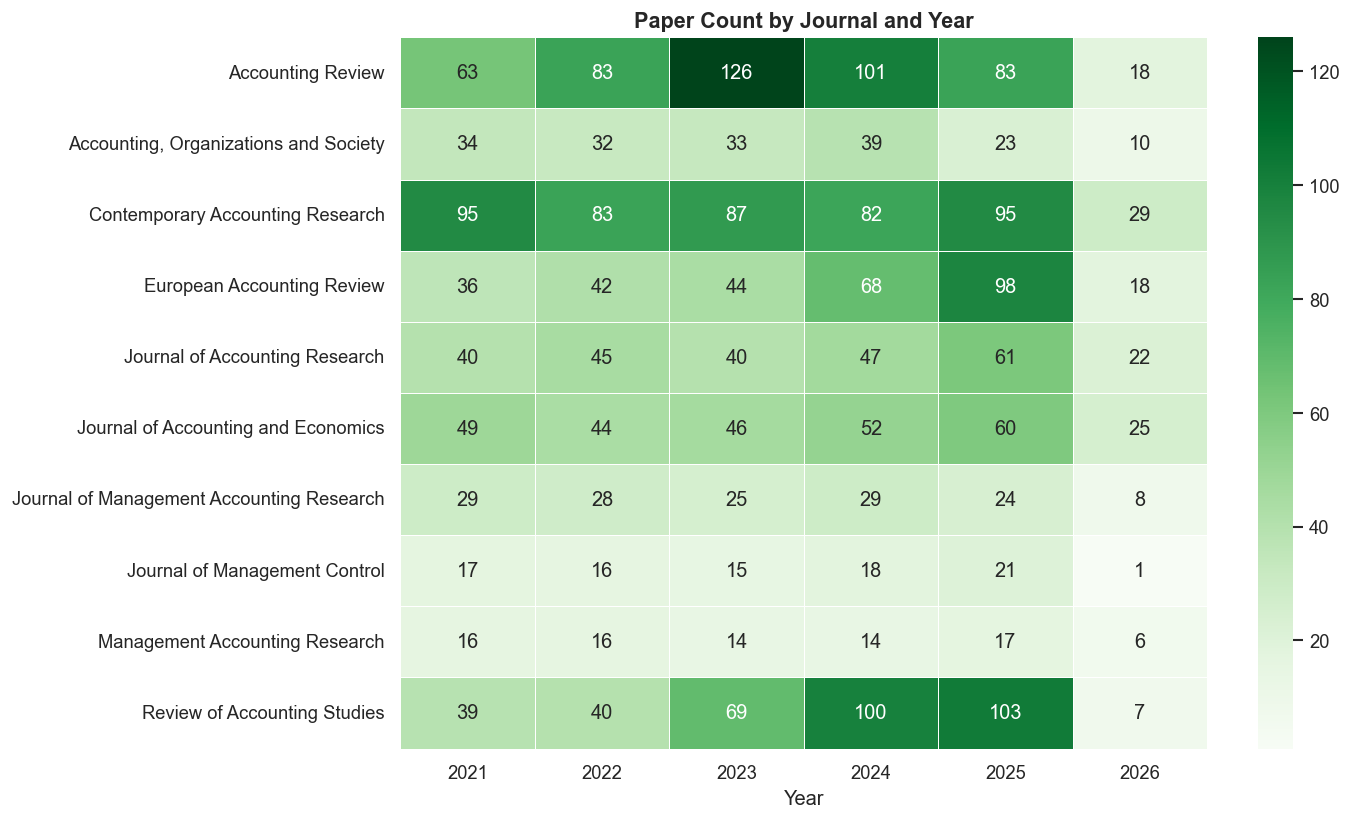

Figure saved as fig_heatmap.png


In [9]:
# ── Heatmap: Journal × Year ────────────────────────────────────────────────────
pivot = (
    df.groupby(["Source title", "Year"])
      .size()
      .unstack(fill_value=0)
)
# Sort columns (years) chronologically
pivot = pivot[sorted(pivot.columns)]

fig, ax = plt.subplots(figsize=(12, max(4, len(pivot) * 0.7)))
sns.heatmap(
    pivot,
    annot=True, fmt="d", cmap="Greens",
    linewidths=0.5, linecolor="white",
    ax=ax
)
ax.set_title("Paper Count by Journal and Year", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("fig_heatmap.png", bbox_inches="tight")
plt.show()
print("Figure saved as fig_heatmap.png")

---

## Step 6 — Abstract Length Analysis

Abstract length (word count) is an indicator of data quality. Very short abstracts may be incomplete records imported from Scopus. We flag any abstract below **30 words** for manual review.

In [10]:
SHORT_ABSTRACT_THRESHOLD = 30

df["abstract_word_count"] = df["Abstract"].str.split().str.len()

print("Abstract word count — descriptive statistics:")
print(df["abstract_word_count"].describe().round(1).to_string())

Abstract word count — descriptive statistics:
count    2625.0
mean      167.2
std        39.1
min        32.0
25%       145.0
50%       158.0
75%       188.0
max       422.0


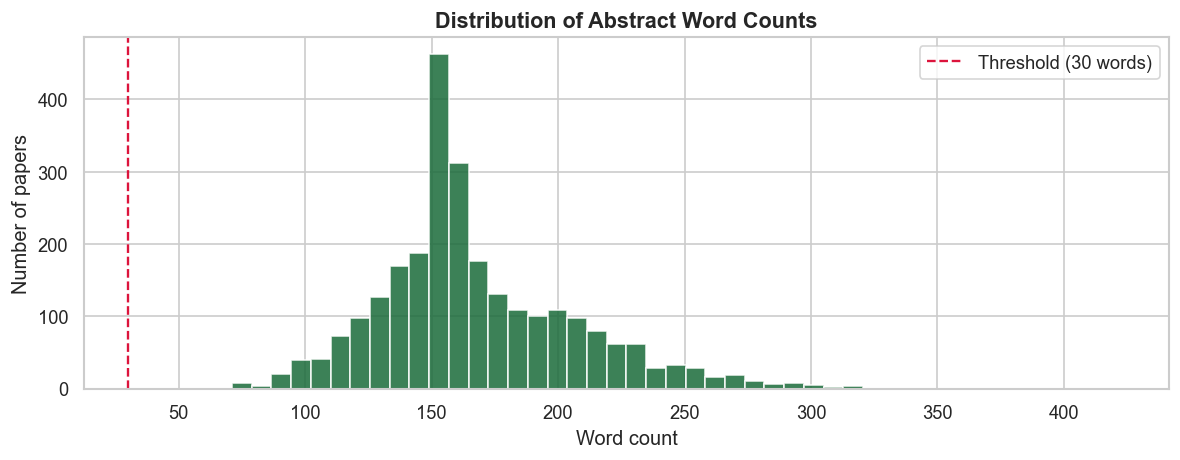

Figure saved as fig_abstract_lengths.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["abstract_word_count"], bins=50, color="#1a6b3a", edgecolor="white", alpha=0.85)
ax.axvline(SHORT_ABSTRACT_THRESHOLD, color="crimson", linestyle="--", linewidth=1.4,
           label=f"Threshold ({SHORT_ABSTRACT_THRESHOLD} words)")
ax.set_title("Distribution of Abstract Word Counts", fontsize=13, fontweight="bold")
ax.set_xlabel("Word count")
ax.set_ylabel("Number of papers")
ax.legend()
plt.tight_layout()
plt.savefig("fig_abstract_lengths.png", bbox_inches="tight")
plt.show()
print("Figure saved as fig_abstract_lengths.png")

In [12]:
short_abstracts = df[df["abstract_word_count"] < SHORT_ABSTRACT_THRESHOLD]
print(f"Papers with fewer than {SHORT_ABSTRACT_THRESHOLD} words in abstract: {len(short_abstracts)}")

if len(short_abstracts) > 0:
    display(
        short_abstracts[["Title", "Source title", "Year", "abstract_word_count", "Abstract"]]
        .sort_values("abstract_word_count")
        .reset_index(drop=True)
    )

Papers with fewer than 30 words in abstract: 0


---

## Step 7 — Management Accounting Filter *(Optional — toggle with flag)*

Although all seven journals are accounting-related, not all papers focus on management accounting topics. We create a boolean flag `is_management_accounting` by checking whether the combined text of Title, Abstract, Author Keywords, and Index Keywords contains any of a predefined set of management accounting terms.

This filter is **optional**: set `APPLY_MA_FILTER = False` to skip it and retain all articles.

In [13]:
# ── Toggle ─────────────────────────────────────────────────────────────────────
APPLY_MA_FILTER = True   # Set to False to disable the filter

# ── Term list ──────────────────────────────────────────────────────────────────
MA_TERMS = [
    "management accounting", "managerial accounting", "management control",
    "cost accounting", "budgeting", "performance measurement", "balanced scorecard",
    "cost management", "management control system", "MCS", "target costing",
    "activity-based costing", "ABC costing", "variance analysis",
    "responsibility accounting", "transfer pricing", "overhead allocation",
    "standard costing", "strategic management accounting"
]

# Build a single regex pattern (word-boundary aware, case-insensitive)
pattern = "|".join(re.escape(term) for term in MA_TERMS)
ma_regex = re.compile(pattern, re.IGNORECASE)

# Combine all searchable text fields
def build_search_text(row):
    parts = [
        str(row.get("text_for_modeling", "")),
        str(row.get("Author Keywords", "")),
        str(row.get("Index Keywords", ""))
    ]
    return " ".join(p for p in parts if p != "nan")

search_text = df.apply(build_search_text, axis=1)
df["is_management_accounting"] = search_text.str.contains(ma_regex)

n_ma = df["is_management_accounting"].sum()
pct_ma = n_ma / len(df) * 100

print(f"Management accounting papers flagged : {n_ma:,} ({pct_ma:.1f}% of {len(df):,} articles)")

# Distribution by journal
print("\nMA flag by journal:")
print(
    df.groupby("Source title")["is_management_accounting"]
      .agg(["sum", "count"])
      .rename(columns={"sum": "MA flagged", "count": "Total"})
      .assign(**{"% MA": lambda x: (x["MA flagged"] / x["Total"] * 100).round(1)})
      .to_string()
)

Management accounting papers flagged : 245 (9.3% of 2,625 articles)

MA flag by journal:
                                           MA flagged  Total  % MA
Source title                                                      
Accounting Review                                  22    474   4.6
Accounting, Organizations and Society              26    171  15.2
Contemporary Accounting Research                   22    471   4.7
European Accounting Review                         29    306   9.5
Journal of Accounting Research                      8    255   3.1
Journal of Accounting and Economics                 6    276   2.2
Journal of Management Accounting Research          35    143  24.5
Journal of Management Control                      51     88  58.0
Management Accounting Research                     40     83  48.2
Review of Accounting Studies                        6    358   1.7


---

## Step 8 — Export

We export two CSV files:

- **`papers_preprocessed.csv`** — all articles after document-type and abstract filters, with all derived columns.
- **`papers_MA_filtered.csv`** — subset flagged as management-accounting-relevant (requires Step 7 flag to be `True`).

In [14]:
# ── Full cleaned dataset ───────────────────────────────────────────────────────
df.to_csv("papers_preprocessed.csv", index=False, encoding="utf-8-sig")
print(f"Saved papers_preprocessed.csv  ({len(df):,} rows, {df.shape[1]} columns)")

# ── MA-flagged dataset (keyword screening across all journals) ─────────────────
df_ma = df[df["is_management_accounting"]].copy()
df_ma.to_csv("papers_MA_filtered.csv", index=False, encoding="utf-8-sig")
print(f"Saved papers_MA_filtered.csv   ({len(df_ma):,} rows)")

# ── MA journals dataset (MAR, JMAR, JOMAC — partial, case-insensitive match) ──
MA_JOURNAL_PATTERNS = [
    "management accounting research",
    "journal of management accounting research",
    "journal of management control",
]

def is_ma_journal(source_title: str) -> bool:
    st_lower = str(source_title).lower()
    return any(pat in st_lower for pat in MA_JOURNAL_PATTERNS)

df_ma_journals = df[df["Source title"].apply(is_ma_journal)].copy()
df_ma_journals.to_csv("papers_MA_journals.csv", index=False, encoding="utf-8-sig")
print(f"Saved papers_MA_journals.csv   ({len(df_ma_journals):,} rows)")

# ── MA strict dataset (MA journals AND MA-flagged) ────────────────────────────
df_ma_strict = df_ma_journals[df_ma_journals["is_management_accounting"] == True].copy()
df_ma_strict.to_csv("papers_MA_strict.csv", index=False, encoding="utf-8-sig")
print(f"Saved papers_MA_strict.csv     ({len(df_ma_strict):,} rows)")

Saved papers_preprocessed.csv  (2,625 rows, 26 columns)
Saved papers_MA_filtered.csv   (245 rows)
Saved papers_MA_journals.csv   (314 rows)
Saved papers_MA_strict.csv     (126 rows)


---

## Step 9 — Summary Report

Final accounting of all filtering steps applied to the dataset.

In [15]:
n_original      = len(df_raw)
n_after_doctype = n_after          # from Step 2
n_after_abs_f   = n_after_abs      # from Step 3
n_final         = len(df)
n_ma_flagged    = int(df["is_management_accounting"].sum())
pct_ma_final    = n_ma_flagged / n_final * 100

n_ma_journals   = len(df_ma_journals)
pct_ma_journals = n_ma_journals / n_final * 100

n_ma_strict     = len(df_ma_strict)
pct_ma_strict   = n_ma_strict / n_final * 100

summary = [
    ("Original rows loaded",                  f"{n_original:>6,}"),
    ("After Document Type filter (Article)",  f"{n_after_doctype:>6,}  (dropped {n_original - n_after_doctype:,})"),
    ("After Abstract filter",                 f"{n_after_abs_f:>6,}  (dropped {n_after_doctype - n_after_abs_f:,})"),
    ("Final row count",                       f"{n_final:>6,}"),
    ("", ""),
    ("── Exported corpora ──",                ""),
    ("papers_preprocessed.csv  (full)",       f"{n_final:>6,}  (100.0%)"),
    ("papers_MA_filtered.csv   (MA_flag)",    f"{n_ma_flagged:>6,}  ({pct_ma_final:.1f}%)"),
    ("papers_MA_journals.csv   (MA_journals)",f"{n_ma_journals:>6,}  ({pct_ma_journals:.1f}%)"),
    ("papers_MA_strict.csv     (MA_strict)",  f"{n_ma_strict:>6,}  ({pct_ma_strict:.1f}%)"),
]

print("=" * 62)
print("  PREPROCESSING PIPELINE — FINAL SUMMARY")
print("=" * 62)
for label, value in summary:
    if label.startswith("──"):
        print(f"\n  {label}")
    elif label:
        print(f"  {label:<42} {value}")
    else:
        print()
print("=" * 62)

  PREPROCESSING PIPELINE — FINAL SUMMARY
  Original rows loaded                        2,675
  After Document Type filter (Article)        2,633  (dropped 42)
  After Abstract filter                       2,625  (dropped 8)
  Final row count                             2,625


  ── Exported corpora ──
  papers_preprocessed.csv  (full)             2,625  (100.0%)
  papers_MA_filtered.csv   (MA_flag)            245  (9.3%)
  papers_MA_journals.csv   (MA_journals)        314  (12.0%)
  papers_MA_strict.csv     (MA_strict)          126  (4.8%)
